In [1]:
import pandas as pd
import dask
import dask.dataframe as ddf
import os
import numpy as np
import sklearn

# Compose a unified full dataset from partial files
#
# Run book_prepare_ce_raw before this


In [2]:


import databox as db

OK -- read the ontology db (19571, 4)
Restored 303734 tags and 191240 tokens. Run update_corpus_tagdata() to update.
-- loaded the skipgram model tank/fasttext_8.model --


In [3]:
tf_df = ddf.read_parquet("data/q_sep/tokenfeat_cat-*.pq")
tf_df=tf_df.compute()

ce_files = [x for x in os.listdir("data/q_sep/") if x.startswith('context_enc_cat_df')]
ce_df = pd.concat([pd.read_parquet("data/q_sep/"+f) for f in ce_files])

In [4]:
tf_df.shape, ce_df.shape

((617837, 6), (54567, 90))

In [5]:
tf_df = tf_df.sort_index()
w_df = ce_df.copy()

In [6]:

def w_win(posi, ctx_len, v_len=90):
    return np.array([8/((i-(90*posi / (ctx_len-.99)))**2+8) for i in range(v_len)])

w_win(4,12)

array([0.00742715, 0.0078994 , 0.00841804, 0.00898933, 0.0096206 ,
       0.01032053, 0.01109941, 0.01196953, 0.01294564, 0.01404559,
       0.01529114, 0.01670901, 0.01833229, 0.02020236, 0.02237147,
       0.02490635, 0.02789322, 0.03144493, 0.03571143, 0.04089503,
       0.04727358, 0.05523617, 0.06533944, 0.07839876, 0.09563963,
       0.11895514, 0.15135135, 0.19771613, 0.26607284, 0.36914231,
       0.52367113, 0.7351814 , 0.94266557, 0.9886946 , 0.82505   ,
       0.60144557, 0.42314181, 0.30176044, 0.22150847, 0.16764141,
       0.13045078, 0.10398968, 0.08462419, 0.07008904, 0.05893384,
       0.05020385, 0.04325371, 0.03763641, 0.03303532, 0.02922161,
       0.02602685, 0.02332499, 0.02102029, 0.01903903, 0.01732372,
       0.01582907, 0.01451894, 0.01336431, 0.0123416 , 0.01143153,
       0.01061819, 0.0098884 , 0.00923112, 0.00863708, 0.00809845,
       0.00760855, 0.0071617 , 0.006753  , 0.00637825, 0.00603378,
       0.00571644, 0.00542344, 0.00515237, 0.0049011 , 0.00466

In [7]:
def wordgram(token_lemmas):
    '''
    Produce a word context embedding vector
    with the skipgram model,
    comparable to the contextual encoding.    
    Input a list of lemmas.
    '''
    v_len = 90
    ctx_len = len(token_lemmas)

    sum_w = np.zeros(v_len)
    
    global lemma_w

    for posi in range(len(token_lemmas)):

        lemma_v = db.skipgram_model[list(token_lemmas)[posi]]
        
        # x_to = range(v_len) 
        # x_from = np.arange(0,90.1,90/7)
        # lemma_w = np.interp(x_to, x_from, lemma_v**4)
        lemma_w = w_win(posi, ctx_len, v_len)
        
        lemma_v = lemma_w * (list(lemma_v)*12)[0:v_len]       
        
        ww = lemma_v
        ww /= np.sqrt((ww**2).sum())
        sum_w += ww

    return sum_w.round(3)

wg = wordgram(['sleep','well','and','tight'])
wg

array([-0.677,  0.536, -0.471, -0.124, -0.046,  0.091, -0.158, -0.068,
       -0.087,  0.065, -0.079, -0.029, -0.01 ,  0.011, -0.044, -0.036,
       -0.049,  0.043, -0.086, -0.041, -0.01 , -0.015, -0.047, -0.086,
       -0.133,  0.145, -0.427, -0.256, -0.056, -0.223, -0.267, -0.459,
       -0.426,  0.253, -0.403, -0.128, -0.018, -0.032, -0.042, -0.064,
       -0.062,  0.05 , -0.093, -0.034, -0.011, -0.009, -0.031, -0.055,
       -0.047,  0.054, -0.107, -0.036, -0.019, -0.022, -0.09 , -0.21 ,
       -0.182,  0.317, -0.731, -0.207, -0.105, -0.135, -0.265, -0.35 ,
       -0.161,  0.147, -0.195, -0.051, -0.029,  0.004, -0.052, -0.071,
       -0.047,  0.039, -0.078, -0.055, -0.048,  0.044, -0.069, -0.082,
       -0.071,  0.043, -0.149, -0.198, -0.215,  0.27 , -0.39 , -0.52 ,
       -0.563,  0.301])

<BarContainer object of 90 artists>

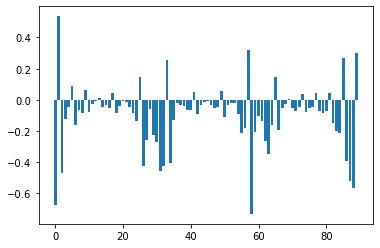

In [8]:
import matplotlib.pyplot as plt
plt.bar(range(90),height=wg)

In [9]:
# Filter out token encodings that do not have any syntactic properties associated (0 coordinates)

w_df = w_df.loc[tf_df.lemma.index.droplevel(2).unique()]
w_df.shape

(54011, 90)

<BarContainer object of 90 artists>

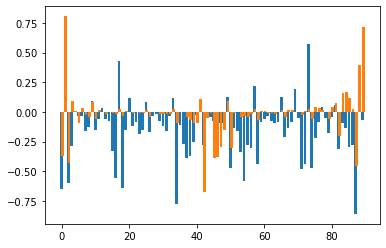

In [10]:
# A visual comparison of two different "word-gram" context encodings

plt.bar(range(90),height=wordgram(tf_df.lemma.loc[w_df.index[9]]))
plt.bar(np.arange(0.2,90),height=wordgram(tf_df.lemma.loc[w_df.index[999]]))

In [11]:
# Build the reference wordgram model

wgs = []

for token_i in range(len(w_df)):
    
    wgs.append(wordgram(tf_df.lemma.loc[w_df.index[token_i]]))
    if 0 == (token_i % 1000):
        print(token_i, len(w_df))
    
wgs_df = pd.DataFrame(wgs,index=w_df.index)    
    


0 54011
1000 54011
2000 54011
3000 54011
4000 54011
5000 54011
6000 54011
7000 54011
8000 54011
9000 54011
10000 54011
11000 54011
12000 54011
13000 54011
14000 54011
15000 54011
16000 54011
17000 54011
18000 54011
19000 54011
20000 54011
21000 54011
22000 54011
23000 54011
24000 54011
25000 54011
26000 54011
27000 54011
28000 54011
29000 54011
30000 54011
31000 54011
32000 54011
33000 54011
34000 54011
35000 54011
36000 54011
37000 54011
38000 54011
39000 54011
40000 54011
41000 54011
42000 54011
43000 54011
44000 54011
45000 54011
46000 54011
47000 54011
48000 54011
49000 54011
50000 54011
51000 54011
52000 54011
53000 54011
54000 54011


In [12]:
# Sanitize indexes (category - token - word index)

w_df.shape, wgs_df.shape

((54011, 90), (54011, 90))

In [13]:
wgs_df = wgs_df.reset_index().set_index(['category','token_id']).sort_index()
w_df = w_df.reset_index().set_index(['category','token_id']).sort_index()
tf_df = tf_df.reset_index().set_index(['category','token','widx']).sort_index()

In [14]:
# Save both context source vectors and feature table and we are good to go

In [15]:
wgs_df.round(3).to_parquet('data/q_sep/wordgram_df.pq')

In [16]:
w_df.round(3).to_parquet('data/q_sep/context_encoding_df.pq')

In [17]:
tf_df.to_parquet('data/q_sep/token_features.pq')

In [18]:
tf_df.head(4)

token_form           concept_uri  \
category   token                    widx                                    
adaptation Aar-5e58_102_predators-8 1     predators  Predation#adaptation   
                                    2     predators  Predation#adaptation   
                                    3     predators  Predation#adaptation   
                                    4     predators  Predation#adaptation   

                                                       arcpath    lemma  upos  \
category   token                    widx                                        
adaptation Aar-5e58_102_predators-8 1     obl<parataxis<nsubj>       it  PRON   
                                    2       obl<parataxis<cop>       be   AUX   
                                    3      obl<parataxis<amod>     keen   ADJ   
                                    4           obl<parataxis<  hearing  NOUN   

                                               sample_grp  
category   token                    widx                   
adaptation Aar-5e58_102_predators-8 1     Snake__suborder  
                                    2     Snake__suborder  
                                    3     Snake__suborder  
                                    4     Snake__suborder